### Parameter calibration at present-day equilibrium

We calibrate the model so that the present-day ice sheet height $h_0 = 3000 \,\mathrm{m}$ is an equilibrium solution when there is no additional warming ($\Delta T = 0$). The value of $h_0$ is chosen to be representative of large ice sheet thickness.

The model describes the evolution of ice sheet height $h(t)$ via
$$
\frac{dh}{dt} = P - \frac{r (T_0 - T_m)^2}{h} - Fh,
$$
where $P$ is the precipitation rate, and $r$ and $F$ control melting and ice flow respectively.

We define $A_0$ as the baseline temperature difference above the melting point:
$$
A_0 = T_0 - T_m \geq 0,
$$
so that the melt term is active at $\Delta T = 0$. Parameters $r$ and $F$ are chosen to be small and of comparable magnitude, ensuring realistic mass balance behaviour.

Imposing the equilibrium condition $\frac{dh}{dt} = 0$ at $h = h_0$ gives
$$
P = \left(F + r A_0^2 \right) h_0.
$$

We fix $r$, $F$, and $A_0$, and compute $P$ accordingly so that $h_0$ is a steady state of the system.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# reference height at present day
h0 = 3000.0

# parameters chosen so the melt term is active at delta t = 0
A0 = 1.0          # = T0 - Tm, must be >= 0 in this model
r = 1e-4
F = 2e-4

# calibrate precipitation so h0 is equilibrium at delta t = 0
P = (F + r*A0**2) * h0

print("P =", P)
print("Check equilibrium at h0:", P - (F + r*A0**2)*h0)

P = 0.9000000000000001
Check equilibrium at h0: 0.0


### Temperature forcing and simplified model dynamics

We represent warming through a scenario-dependent melt factor
$$
A = T_0 + \Delta T - T_m.
$$

Rather than modelling $\Delta T(t)$ explicitly, we consider discrete scenarios:
- **baseline**: $A = A_0$
- **low warming**: $A = A_0 + 0.5$
- **high warming**: $A = A_0 + 1.5$

For simplicity, the melt term is approximated as proportional to $h$, yielding a linear model that allows the equilibrium structure to be analysed more easily, giving
$$
\frac{dh}{dt} = P - \left(F + rA^2 \right) h.
$$

In this reduced model, increased warming (larger $A$) increases the effective mass-loss rate and lowers the equilibrium ice height.

In [41]:
def melt_factor(scenario):
    if scenario == "low":
        return A0 + 0.5
    elif scenario == "high":
        return A0 + 1.5
    else:
        return A0
    
def dhdt_base(t, h, scenario):  # t included for compatibility with solve_ivp (autonomous system)
    A = melt_factor(scenario)
    return P - (F + r*A**2) * h

In [42]:
t_span = (0, 2000) # long-term integration horizon
t_eval = np.linspace(*t_span, 1000)

def simulate(scenario): # numerically integrates the base model for a given warming scenario
    sol = solve_ivp(
        lambda t, h: dhdt_base(t, h, scenario),
        t_span,
        [h0],
        t_eval=t_eval
    )
    return sol.t, sol.y[0]

In [43]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})

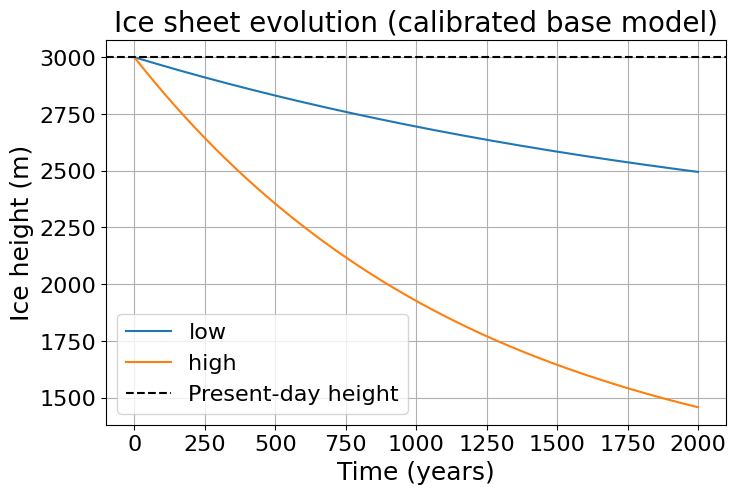

In [44]:
plt.figure(figsize=(8,5))

for scenario in ["low", "high"]:
    t, h = simulate(scenario)
    plt.plot(t, h, label=scenario)

plt.axhline(h0, linestyle='--', color='black', label='Present-day height')
plt.xlabel("Time (years)")
plt.ylabel("Ice height (m)")
plt.title("Ice sheet evolution (calibrated base model)")
plt.legend()
plt.grid()
plt.show()

### Equilibrium structure under warming

We examine the equilibria by plotting $\frac{dh}{dt}$ as a function of ice height $h$ for different values of the melt factor $A$.

Equilibria occur where $\frac{dh}{dt} = 0$. As $A$ increases (stronger warming), the lines shift downward, reducing the equilibrium ice height
$$
h^* = \frac{P}{F + rA^2},
$$
where $h^*$ denotes the steady-state (equilibrium) ice height.


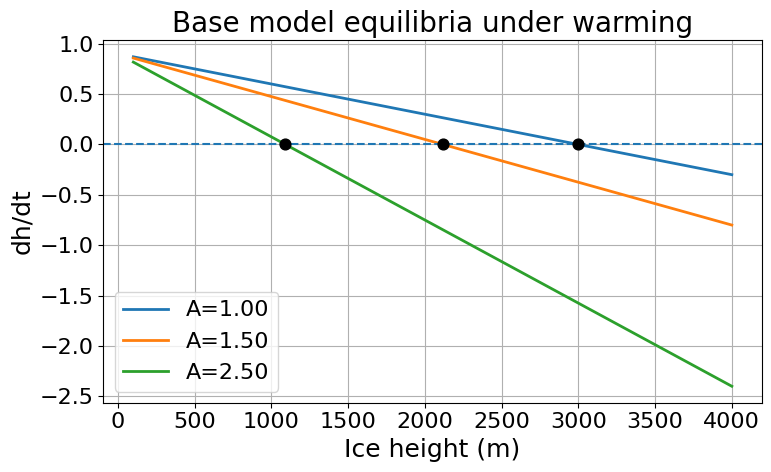

In [45]:
h_vals = np.linspace(100, 4000, 500)

plt.figure(figsize=(8,5))

for A in [A0, A0+0.5, A0+1.5]:
    dh_vals = [P - (F + r*A**2)*h for h in h_vals]
    plt.plot(h_vals, dh_vals, label=f"A={A:.2f}", linewidth=2)

for A in [A0, A0+0.5, A0+1.5]:
    h_eq = P / (F + r*A**2)
    plt.scatter(h_eq, 0, color='black', s=60, zorder=5)

plt.axhline(0, linestyle='--', linewidth=1.5)

# BIG fonts
plt.xlabel("Ice height (m)", fontsize=18)
plt.ylabel("dh/dt", fontsize=18)
plt.title("Base model equilibria under warming", fontsize=20)

plt.legend(fontsize=16)

# Big tick labels
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.grid()
plt.tight_layout()
plt.savefig("base-eq.pdf", bbox_inches="tight")
plt.show()

### Extended model parameters

The extended model introduces melt sensitivity ($\mu$), a characteristic height scale ($h_c$), and nonlinear flow parameters ($k, n$). Values are chosen to be physically reasonable and to produce meaningful nonlinear behaviour.

- $h_c = 1500\,\mathrm{m}$: comparable to ice sheet thickness, setting the scale at which feedbacks become important  
- $\mu = 1.2$: moderate melt sensitivity, ensuring a noticeable but not extreme response to warming  
- $k = 5 \times 10^{-8}$, $n = 2$: introduce nonlinear flow while maintaining stable dynamics under present conditions

In [ ]:
# extended model parameters
mu = 1.2      # melt sensitivity
h_c = 1500.0  # characteristic height scale (m)
k = 5e-8      # nonlinear flow coefficient
n = 2         # flow exponent

### Extended model dynamics

The extended model introduces height-dependent feedbacks and nonlinear ice flow. The governing equation becomes
$$
\frac{dh}{dt} = P - \left(F + rA^2 \left(1 + \mu \frac{h_c}{h + h_c}\right)\right) h - k h^n.
$$

The melt term is now amplified by a height-dependent feedback, which becomes stronger as ice height decreases. This reflects the effect of warmer air at lower altitudes, making a thinner ice sheet more vulnerable to melting. In contrast, the nonlinear flow term increases with ice height, as thicker ice experiences greater gravitational driving stress, leading to faster flow and increased mass loss.

These feedbacks allow for more complex behaviour, including the potential for rapid ice loss under warming.

In [48]:
def dhdt_extended(t, h, scenario):
    A = melt_factor(scenario)

    # feedback increases loss as h decreases
    feedback = 1 + mu * (h_c / (h + h_c))

    return P - (F + r*A**2 * feedback) * h - k * h**n

In [49]:
def simulate_extended(scenario): # same simulation as before just using extended model dh/dt function
    sol = solve_ivp(
        lambda t, h: dhdt_extended(t, h, scenario),
        t_span,
        [h0],
        t_eval=t_eval
    )
    return sol.t, sol.y[0]

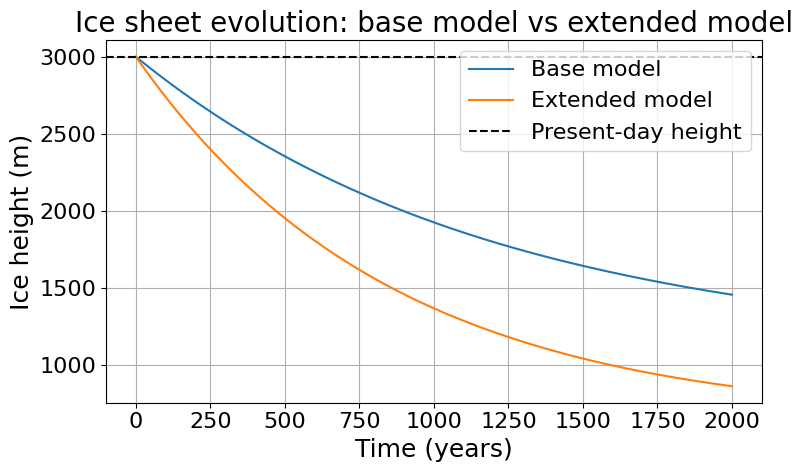

In [50]:
plt.figure(figsize=(8,5))

t1, h1 = simulate("high")
t2, h2 = simulate_extended("high")

plt.plot(t1, h1, label="Base model")
plt.plot(t2, h2, label="Extended model")

plt.axhline(h0, linestyle='--', color='black', label='Present-day height')
plt.xlabel("Time (years)")
plt.ylabel("Ice height (m)")
plt.title("Ice sheet evolution: base model vs extended model")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("ice-sheet.pdf", bbox_inches="tight")
plt.show()

### Sea level response

Sea level rise is estimated from ice height loss via
$$
S(h) = S_{\max} \frac{h_0 - h}{h_0},
$$
where $S_{\max} = 7.5\,\mathrm{m}$ represents complete ice sheet loss.


<Figure size 800x500 with 0 Axes>

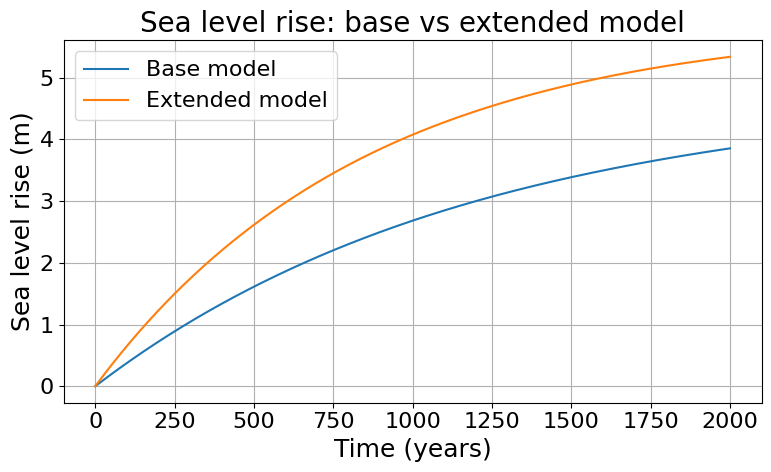

In [51]:
S_max = 7.5  # total possible sea level rise (m)

def sea_level(h):
    return S_max * (h0 - h) / h0
plt.figure(figsize=(8,5))

plt.figure(figsize=(8,5))

t1, h1 = simulate("high")
t2, h2 = simulate_extended("high")

plt.plot(t1, sea_level(h1), label="Base model")
plt.plot(t2, sea_level(h2), label="Extended model")

#plt.axhline(7.5, linestyle='--', color='black', label='Full melt (~7.5m)')
plt.xlabel("Time (years)")
plt.ylabel("Sea level rise (m)")
plt.title("Sea level rise: base vs extended model")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("sea-level.pdf", bbox_inches="tight")
plt.show()

### Equilibria in the extended model

We again plot $\frac{dh}{dt}$ against $h$ to identify equilibria under different warming scenarios.

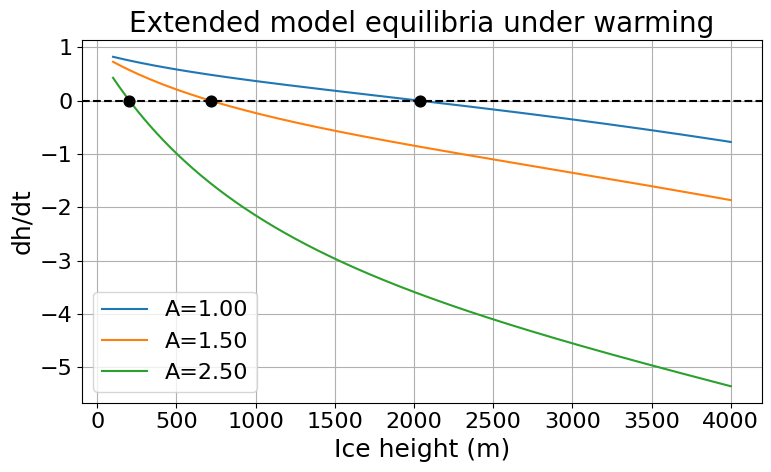

In [52]:
h_vals = np.linspace(100, 4000, 500)

plt.figure(figsize=(8,5))

for A in [A0, A0 + 0.5, A0 + 1.5]:
    dh_vals = P - mu * A**2 * (h_vals / (h_vals + h_c)) - k * h_vals**n

    # Plot curve
    plt.plot(h_vals, dh_vals, label=f"A={A:.2f}")

    # Find equilibrium (where dh/dt ≈ 0)
    idx = np.argmin(np.abs(dh_vals))   # closest to zero
    h_eq = h_vals[idx]

    # Plot dot
    plt.scatter(h_eq, 0, color='black', s=60, zorder=5)

plt.axhline(0, linestyle='--', color='black')
plt.xlabel("Ice height (m)")
plt.ylabel("dh/dt")
plt.title("Extended model equilibria under warming")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("eq-ext.pdf", bbox_inches="tight")
plt.show()